# Power Spectral Density (PSD) of Sea Level Anomaly in the Baltic Sea

This tutorial compares the power spectral density (PSD) of sea level anomaly (SLA) / sea surface height anomaly (SSHA) derived from four altimetry products over the Baltic Sea, 29 March - 9 July 2023:

- **FFSAR**: Fully-Focused SAR altimetry OI SLA with geostrophic velocities (IGG, University of Bonn), L4
- **RADS**: Conventional radar altimetry OI SLA with geostrophic velocities (IGG, University of Bonn), L4
- **SL TAC**: Copernicus Marine Service (CMEMS) DUACS all-satellite merged L4 SLA product, European Seas
- **SWOT**: SWOT KaRIn L3 SSHA, 1-day cal/val phase (AVISO/CNES/CLS DUACS)

The notebook computes along-track power spectra for each product and plots the mean PSD and time series to characterize the resolved mesoscale/submesoscale wavelengths.

**Data**: the notebook downloads the required NetCDF files (~900 MB) from Zenodo the first time it is run (see the next cell). See `README.md` for data provenance, licensing, and how to run this tutorial on [EDITO Datalab](https://datalab.dive.edito.eu/).

In [1]:
## Setup: install missing packages and download the tutorial data from Zenodo
%pip install -q netCDF4 geopy

import os
import tarfile
import urllib.request

ZENODO_RECORD = "10.5281/zenodo.22771211"
DATA_URL = f"https://zenodo.org/records/{ZENODO_RECORD.split('.')[-1]}/files/4dbalt.tar.gz?download=1"

workdir = "4dbalt"
archive_path = "4dbalt.tar.gz"

if not os.path.isdir(workdir):
    if not os.path.exists(archive_path):
        print(f"Downloading tutorial data from Zenodo ({DATA_URL})...")
        urllib.request.urlretrieve(DATA_URL, archive_path)
    print("Extracting data...")
    with tarfile.open(archive_path) as tar:
        tar.extractall(".")
    print("Done.")
else:
    print(f"'{workdir}' already present, skipping download.")

Note: you may need to restart the kernel to use updated packages.
Extracting data...


/tmp/ipykernel_88/2157058178.py:20: DeprecationWarning: Python 3.14 will, by default, filter extracted tar archives and reject files or modify their metadata. Use the filter argument to control this behavior.
  tar.extractall(".")


Done.


## 1. Imports

In [2]:
import numpy as np

import matplotlib.pyplot as plt

from netCDF4 import Dataset

from scipy.stats import binned_statistic
from scipy.signal import detrend
from geopy import distance as dist

def namestr(obj, namespace = globals()):
    return [name for name in namespace if namespace[name] is obj][0] 

In [3]:
import os 

def get_dsets(folder_path, pass_number = None) :    
    files = [f for f in os.listdir(folder_path) if not f.startswith('.')][:300]  # skip hidden/AppleDouble junk files

    dsets = []
    if pass_number : 
        for file in files : 
            if file[25:28]==pass_number : #filtering by pass number if specified. 
                dsets.append(Dataset( folder_path + '/' + file, 'r'))
    else : 
        for file in files : 
            if file[-3:] == '.nc' :
                dsets.append(Dataset( folder_path + '/' + file, 'r'))
    return dsets

# for a folder with daily data files, dsets[5] gives the full dataset of the 6th day

def get_data(dsets, dataname) : 
    data_days = [dset_day[dataname][:][:][:] for dset_day in dsets]
    return data_days

# data_days[i] is the wanted data on the i+1-th day, masked array of shape (1, nx, ny). data_days is of shape (ndays, 1, nx, ny)

#### Importing the data

In [4]:
## FFSAR and RADS datasets for the period 29/03/23 to 09/07/23

var = 'sla'

dsets_ffsar_f1d = get_dsets(f'{workdir}/FFSAR_0323to0723') #get_dsets provides all datasets in the given folder path
dsets_rads_f1d = get_dsets(f'{workdir}/RADS_0323to0723')

sla_ffsar_f1d, lats_ffsar_f1d, longs_ffsar_f1d = get_data(dsets_ffsar_f1d, var), get_data(dsets_ffsar_f1d, 'latitude'), get_data(dsets_ffsar_f1d, 'longitude')
sla_rads_f1d, lats_rads_f1d, longs_rads_f1d = get_data(dsets_rads_f1d, var), get_data(dsets_rads_f1d, 'latitude'), get_data(dsets_rads_f1d, 'longitude')

time_ffsar_f1d, time_rads_f1d = get_data(dsets_ffsar_f1d, 'time'), get_data(dsets_rads_f1d, 'time')

print(sla_rads_f1d[0].shape, len(lats_rads_f1d[0]))

(1, 106, 172) 106


In [5]:
## SL TAC dataset for the period 29/03/23 to 09/07/23

var = 'sla'

dsets_sltac_f1d = get_dsets(f'{workdir}/SLTAC_0323to0723') #get_dsets provides all datasets in the given folder path

sla_sltac_f1d, lats_sltac_f1d, longs_sltac_f1d = get_data(dsets_sltac_f1d, var), get_data(dsets_sltac_f1d, 'latitude'), get_data(dsets_sltac_f1d, 'longitude')
time_sltac_f1d = get_data(dsets_sltac_f1d, 'time')


In [6]:
## SWOT calval phase dataset (period 29/03/23 to 09/07/23)

var = 'ssha_filtered'

dsets_calval14 = get_dsets(f'{workdir}/SWOT_1dayCalval', pass_number = '014')

ssha_calval14, lats_calval14, longs_calval14 = get_data(dsets_calval14, var), get_data(dsets_calval14, 'latitude'), get_data(dsets_calval14, 'longitude')
time_calval14 = get_data(dsets_calval14, 'time')
ssha_calval14[0].shape

(9860, 69)

## 2. Parameters

##### Visualize the data, set domain limits and choose lines for PSD computation

In [7]:
## To simplify further computation, all data and parameters relative to a database are stored in dictionnaries. Minimal keys required are stored below

keys = ['lowpoint', 'highpoint', 'leftpoint', 'lines', 'data', 'label', 'lats', 'lons', 'days']

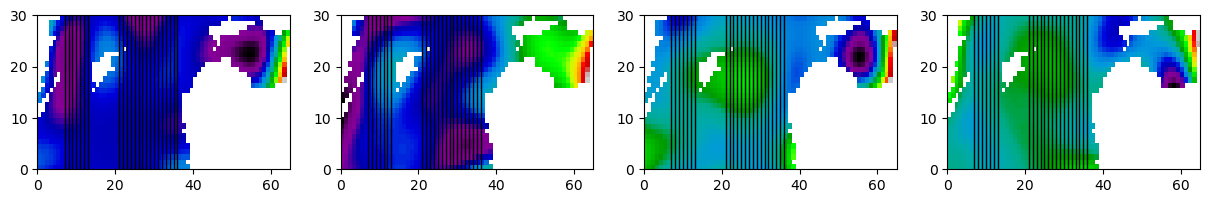

In [8]:
store = dict.fromkeys(keys) 

##input the right datasets and informations
store['data'], store['label'] = sla_ffsar_f1d, 'SLA FFSAR, 03/23-07/23'
store['level'] = 'L4'

store['lats'] = lats_ffsar_f1d
store['lons'] = longs_ffsar_f1d 
store['time'] = time_ffsar_f1d 

##define limits of the domain
store['lowpoint'] = 17
store['highpoint'] = 47
store['leftpoint'] = 55
store['rightpoint'] = 120
##choose lines on wich to compute PSD. Note that masked areas should be avoided as much as possible
store['lines'] = [i for i in range(7, 14)] + [i for i in range(21, 37, 1)] 

##visualization on first 4 datasets in 'data' list with previous settings, no change to be made
##in black are lines selected for PSD computation (defined in 'lines')
fig, ax = plt.subplots(1, 4, figsize = (15,2))
for i in range(4): 
    plt.sca(ax[i])
    plt.pcolor(store['data'][i][0, store['lowpoint']:store['highpoint'], store['leftpoint']:store['rightpoint']], cmap = 'nipy_spectral')
    for line_p in store['lines'] : 
        plt.axvline(x=line_p, color='black', linewidth = 1)

## days (or cycles) for which PSD will be computed. I remove days with suspected anomalies
store['days'] = [i for i in range(1, len(store['data'])+1) if i not in (15, 30, 39, 44, 53, 76, 89)]

## name this cell's data for simple access later, here ffsar
ffsarf1d = store 

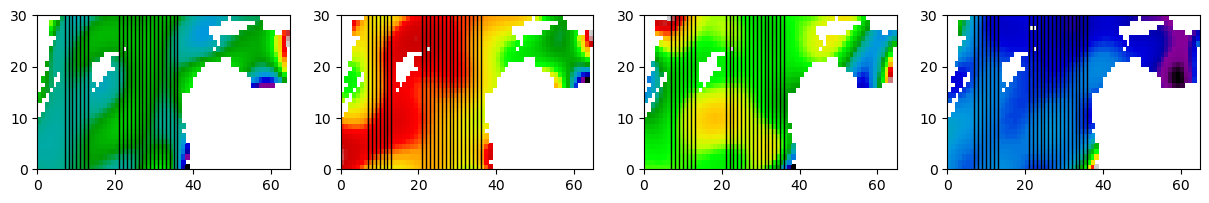

In [9]:
store = dict.fromkeys(keys) 

##input the right datasets and informations
store['data'], store['label'] = sla_rads_f1d, 'SLA RADS, 03/23-07/23'
store['level'] = 'L4'

store['lats'] = lats_rads_f1d
store['lons'] = longs_rads_f1d 
store['time'] = time_rads_f1d 

##define limits of the domain
store['lowpoint'] = 17
store['highpoint'] = 47
store['leftpoint'] = 55
store['rightpoint'] = 120
##choose lines on wich to compute PSD. Note that masked areas should be avoided as much as possible
store['lines'] = [i for i in range(7, 14)] + [i for i in range(21, 37, 1)] #np.arange(21, 37, 1)

##visualization on first 4 datasets in 'data' list with previous settings, no change to be made
##in black are lines selected for PSD computation (defined in 'lines')
fig, ax = plt.subplots(1, 4, figsize = (15,2))
for i in range(4): 
    plt.sca(ax[i])
    plt.pcolor(store['data'][i][0, store['lowpoint']:store['highpoint'], store['leftpoint']:store['rightpoint']], cmap = 'nipy_spectral')
    for line_p in store['lines'] : 
        plt.axvline(x=line_p, color='black', linewidth = 1)


store['days'] = [i for i in range(1, len(store['data'])+1) if i not in (10, 31, 47, 56, 63, 67, 97)]

radsf1d = store 

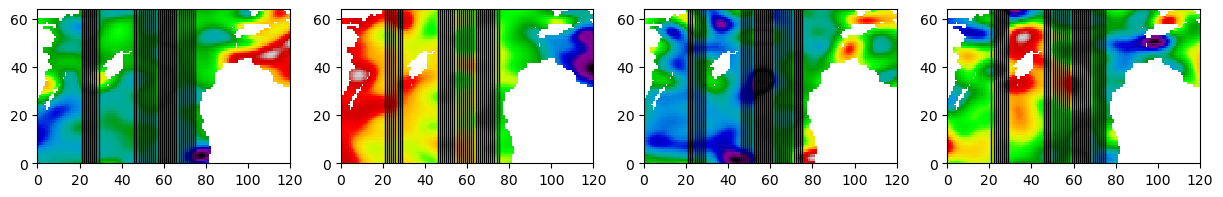

In [10]:
store = dict.fromkeys(keys) 

##input the right datasets and informations
store['data'], store['label'] = sla_sltac_f1d, 'SLA SL TAC, 03/23-07/23'
store['level'] = 'L4'

store['lats'] = lats_sltac_f1d
store['lons'] = longs_sltac_f1d
store['time'] = time_sltac_f1d

##define limits of the domain
store['lowpoint'] = 560
store['highpoint'] = 624
store['leftpoint'] = 740
store['rightpoint'] = 860
##choose lines on wich to compute PSD. Note that masked areas should be avoided as much as possible
store['lines'] = [i for i in range(21, 30)] + [i for i in range(46, 76)]

##visualization on first 4 datasets in 'data' list with previous settings, no change to be made
##in black are lines selected for PSD computation (defined in 'lines')
fig, ax = plt.subplots(1, 4, figsize = (15,2))
for i in range(4): 
    plt.sca(ax[i])
    plt.pcolor(store['data'][i][0, store['lowpoint']:store['highpoint'], store['leftpoint']:store['rightpoint']], cmap = 'nipy_spectral')
    for line_p in store['lines'] : 
        plt.axvline(x=line_p, color='black', linewidth = 1)


store['days'] = np.arange(1, len(store['data'])+1) 

sl_tacf1d = store 

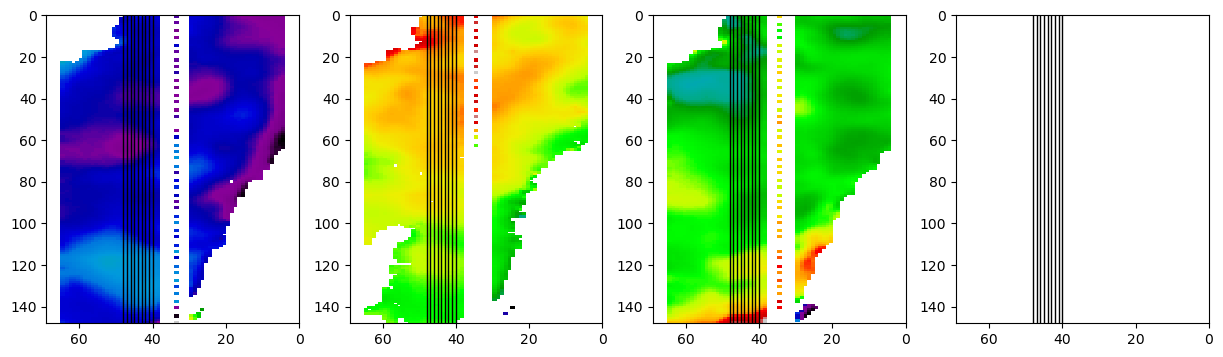

In [11]:
store = dict.fromkeys(keys, 0)

##input the right datasets and informations
store['data'], store['label'] = ssha_calval14, 'SSHA 1-day SWOT half-orbit 14'
store['level'] = 'L3'

store['lats'] = lats_calval14
store['lons'] = longs_calval14
store['time'] = time_calval14

##define limits of the domain
store['lowpoint'] = 1650
store['highpoint'] = 1798
##choose lines on wich to compute PSD. Note that masked areas should be avoided as much as possible
store['lines'] = [i for i in range(40, 49)] 

##visualization on first 4 datasets in 'data' list with previous settings, no change to be made
##in black are lines selected for PSD computation (defined in 'lines')
fig, ax = plt.subplots(1, 4, figsize = (15,4))
for i in range(4): 
    plt.sca(ax[i])
    plt.pcolor(store['data'][i][store['lowpoint']:store['highpoint'], :], cmap = 'nipy_spectral')
    for line_p in store['lines'] : 
        plt.axvline(x=line_p, color='black', linewidth = 1)
    ax[i].invert_yaxis()
    ax[i].invert_xaxis() ##orbit 14 is upwards, mirroring the image so it matches northern visual better

store['days'] = [i for i in range(1, len(store['data'])+1) if i not in (4,)] 

swot1day = store 

## 3. Results

##### Plot power spectrum and SLA profile for 1 database

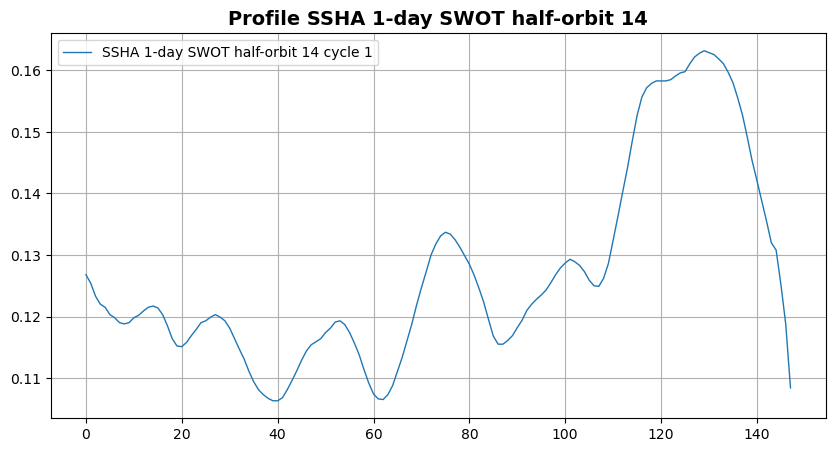

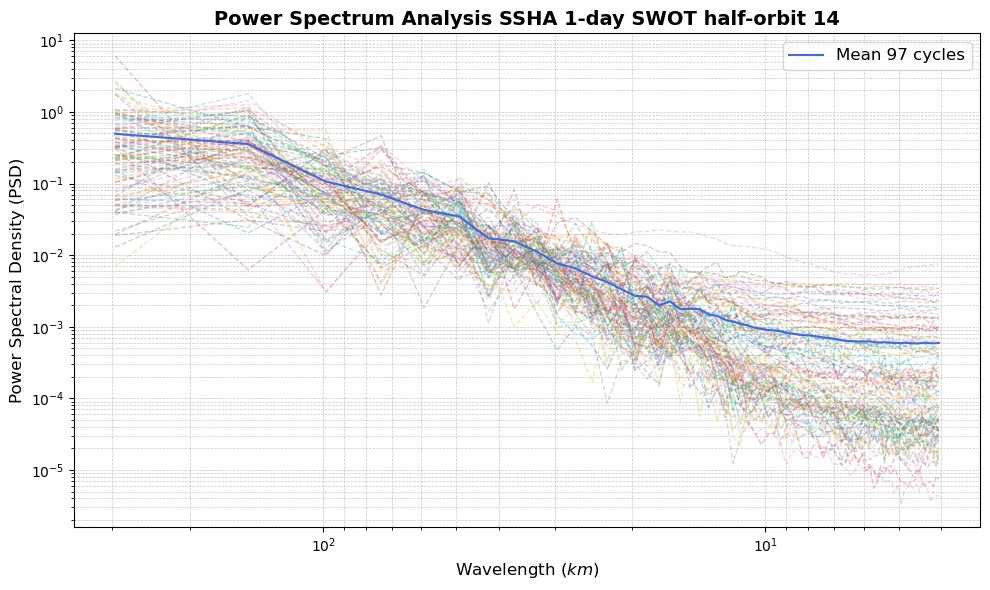

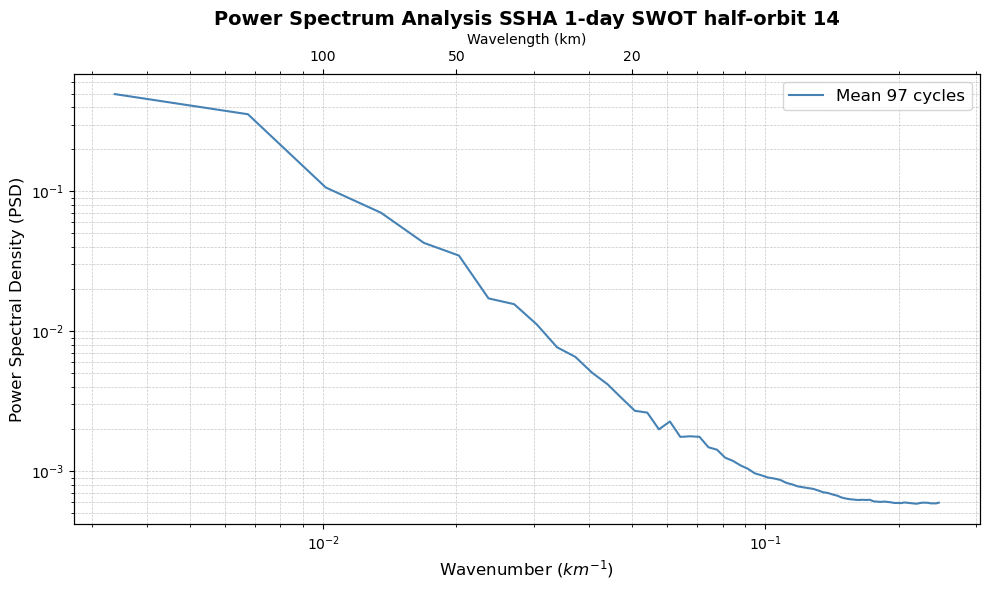

In [12]:
##Choose source here
data_store = swot1day

##specify sampling interval for L3 data of constant step, here 2km SWOT
samp_intL3 = 2. #km 


#####
# No change to be made below this
#####

level = data_store['level']

def line_power_spectrum(image, yyp, xp, lats, longs, normalize=None):
    if len(image.shape) == 3 :
        line_values = image[0, yyp[0]:yyp[1], xp].filled(0)
    else :
        line_values = image[yyp[0]:yyp[1], xp].filled(0)

    if normalize == 'Mean': 
        line_values = line_values / np.mean(line_values)
    if normalize == 'CR':
        line_values = (line_values - np.mean(line_values)) / np.std(line_values)
    
    line_values = detrend(line_values, type='linear') ### Detrending
    line_values -= np.mean(line_values) ### Removing mean
    fourier_line = np.fft.fft(line_values) 
    power_spectrum = np.abs(fourier_line) ** 2

    n = len(line_values)
    kfreq = np.fft.fftfreq(n) * n
    kfreq = np.abs(kfreq)

    if level == 'L4' : 
        no, so, ea = lats[0][yyp[0]], lats[0][yyp[1]], longs[0][xp]
        km_line = dist.distance((no, ea), (so, ea)).km
        samp_int = km_line/n
    else : 
        samp_int = samp_intL3

    kbins = np.arange(0.5, n / 2, 1.)
    kvals = 0.5 * (kbins[1:] + kbins[:-1])
    Abins, _, _ = binned_statistic(kfreq, power_spectrum, statistic="mean", bins=kbins)
    return kvals/samp_int, Abins, line_values


images = [data_store['data'][i-1] for i in data_store['days']]
yyp = (data_store['lowpoint'], data_store['highpoint'])
xps = [line_p+data_store['leftpoint'] for line_p in data_store['lines']]
lats = data_store['lats']
longs = data_store['lons']

dayorcycle = 'day' if level == 'L4' else 'cycle'

#### Plot SLA profile for the first day / cycle

def extract_line_values(image, yyp, xp):
    if len(image.shape) == 3 :
        return image[0, yyp[0]:yyp[1], xp]
    else :
        return image[yyp[0]:yyp[1], xp]

values_day1 = extract_line_values(images[0], yyp, xps[0])

plt.figure(figsize=(10, 5))
plt.plot([i for i in range(len(values_day1))], values_day1, label= data_store['label'] + ' ' + dayorcycle + ' 1', linestyle='-', linewidth=1) #
plt.title('Profile ' + data_store['label'], fontsize=14, fontweight='bold')
plt.legend()
plt.grid()
plt.show()


#### Plot PS for all days / cycles

normalization = ''

ktruth, _, line_values = line_power_spectrum(images[0], yyp, xps[0], lats, longs, normalization)

singles_A = []
for image_day in images:
    for xp in xps : 
        _, atr, _ = line_power_spectrum(image_day, yyp, xp, lats, longs, normalization)
        singles_A.append(atr)

Atruth = np.mean(singles_A, 0)
    
npix = len(line_values)

fig, ax = plt.subplots(figsize=(10, 6))

# Plot with enhanced line styles and colors
for i in range(len(images)) : 
    mean_1cycle = np.mean([singles_A[i*len(xps)+j] for j in range(len(xps))], 0)
    ax.loglog(npix / ktruth, mean_1cycle, linewidth=1., linestyle='--', alpha = 0.3) 
    if mean_1cycle[-1] > 1e-2 :
        print('Anomaly for ' + dayorcycle + ' ' + str(i+1))
ax.loglog(npix / ktruth, Atruth, label='Mean ' + str(len(data_store['days'])) + ' ' + dayorcycle + 's', color = 'royalblue', linewidth=1.5, linestyle='-')


# Add a grid for better readability of logarithmic scales
ax.grid(True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)

# Add labels, title, and legend
ax.set_xlabel('Wavelength ($km$)', fontsize=12)
ax.set_ylabel('Power Spectral Density (PSD)', fontsize=12)
ax.set_title('Power Spectrum Analysis ' + data_store['label'], fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

ax.tick_params(axis='both', which='major', labelsize=10)
ax.invert_xaxis()  # Invert x-axis as per the original

# Display the plot
plt.tight_layout()
plt.show()


#### Plot mean of all the PS 

fig, ax = plt.subplots(figsize=(10, 6))

# Plot with enhanced line styles and colors
ax.loglog(ktruth /npix, Atruth, label='Mean ' + str(len(data_store['days'])) + ' ' + dayorcycle + 's', color = 'steelblue', linewidth=1.5, linestyle='-')

# Add a grid for better readability of logarithmic scales
ax.grid(True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)

# Add labels, title, and legend
ax.set_xlabel('Wavenumber ($km^{-1}$)', fontsize=12)
ax.set_ylabel('Power Spectral Density (PSD)', fontsize=12)
ax.set_title('Power Spectrum Analysis ' + data_store['label'], fontsize=14, fontweight='bold')
ax.legend(fontsize=12)

xax2 = ax.twiny()
xax2.set_xscale('log')
xax2.set_xlabel('Wavelength (km)')
xax2.set_xticks([1/20, 1/50, 1/100, 1/500], labels = ['20', '50', '100', '500'])
xax2.set_xlim(ax.get_xlim())

ax.tick_params(axis='both', which='major', labelsize=10)

# Display the plot
plt.tight_layout()
plt.show()

##### Plot power spectra and time series for different databases

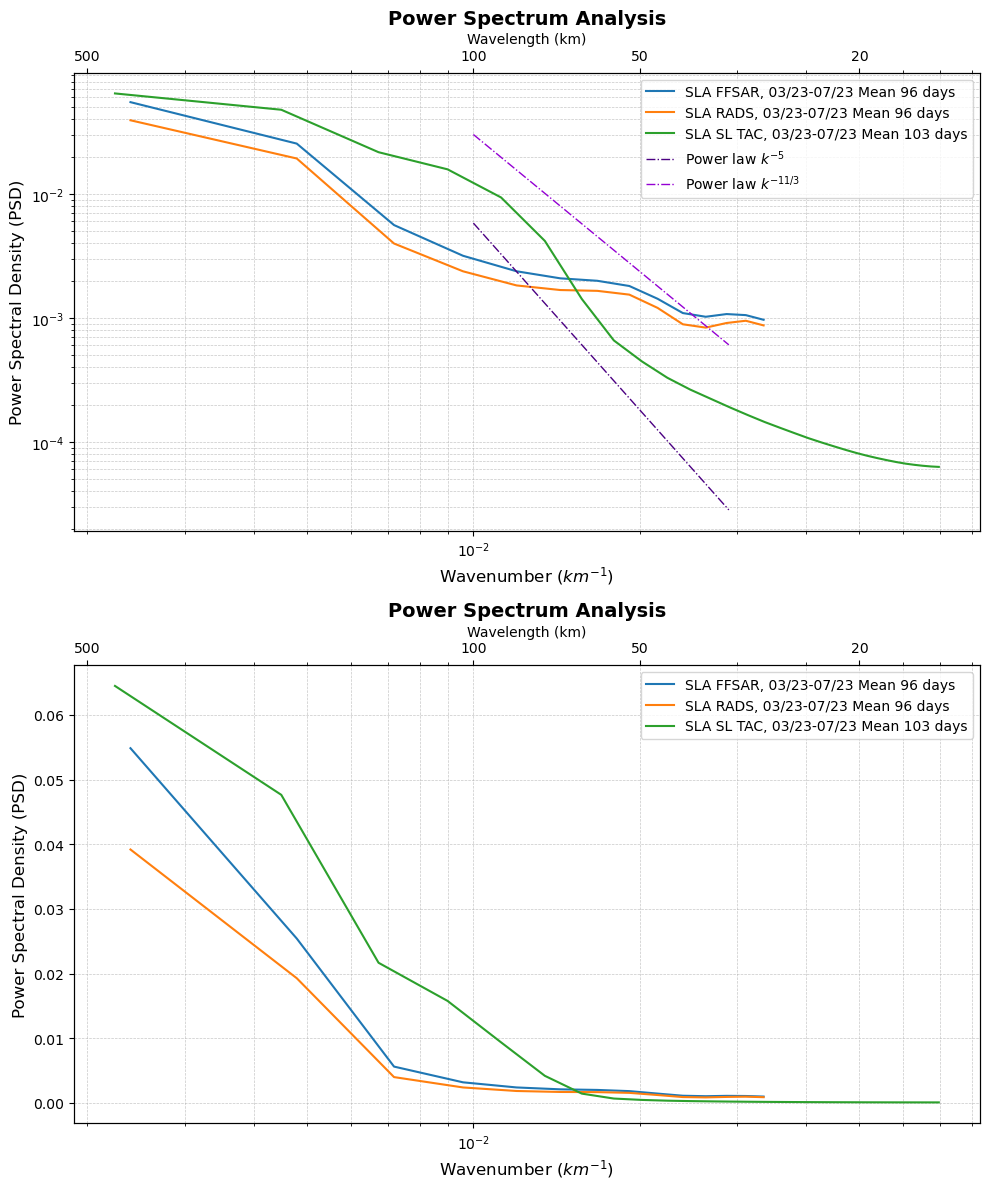

In [13]:
## POWER SPECTRA - loglog and linlog

##Choose sources here
data_stores = ffsarf1d, radsf1d, sl_tacf1d 


#####
# No changes to be made below this
#####
images_list = [[data_store['data'][i-1] for i in data_store['days']] for data_store in data_stores]
yyp_list = [(data_store['lowpoint'], data_store['highpoint']) for data_store in data_stores]
xps_list = [[line_p+data_store['leftpoint'] for line_p in data_store['lines']] for data_store in data_stores]
lats_list = [data_store['lats'] for data_store in data_stores]
longs_list = [data_store['lons'] for data_store in data_stores]
level_list = [data_store['level'] for data_store in data_stores]

dayorcycle_list = ['day' if level == 'L4' else 'cycle' for level in level_list]

fig, ax = plt.subplots(2, 1, figsize=(10, 12))

normalization = ''

for i in range(len(data_stores)):
    level = level_list[i]
    ktruth, _, line_values = line_power_spectrum(images_list[i][0], yyp_list[i], xps_list[i][0], lats_list[i], longs_list[i], normalization)

    singles_A = []
    for image_day in images_list[i]:
        for xp in xps_list[i] : 
            atr = line_power_spectrum(image_day, yyp_list[i], xp, lats_list[i], longs_list[i], normalization)[1]
            singles_A.append(atr)

    Atruth = np.mean(singles_A, 0)
        
    npix = len(line_values)

    ax[0].loglog(ktruth /npix, Atruth, label= data_stores[i]['label'] + ' Mean ' + str(len(data_stores[i]['days'])) + ' ' + dayorcycle_list[i] + 's', linewidth=1.5, linestyle='-')
    ax[1].semilogx(ktruth /npix, Atruth, label= data_stores[i]['label'] + ' Mean ' + str(len(data_stores[i]['days'])) + ' ' + dayorcycle_list[i] + 's', linewidth=1.5, linestyle='-')

#### Plot power laws
kpl = np.arange(1e-2, 3e-2, 1e-3)
Pl5 = (kpl*2.8e2)**(-5)
Pl113 = (kpl*2.6e2)**(-11/3)
ax[0].loglog(kpl, Pl5, '-.', label = 'Power law $k^{-5}$', color = 'indigo', linewidth = 1.)
ax[0].loglog(kpl, Pl113, '-.', label = 'Power law $k^{-11/3}$', color = 'darkviolet', linewidth = 1.)

for axe in ax : 
    # Add a grid for better readability of logarithmic scales
    axe.grid(True, which="both", linestyle='--', linewidth=0.5, alpha=0.7)

    # Add labels, title, and legend
    axe.set_xlabel('Wavenumber ($km^{-1}$)', fontsize=12)
    axe.set_ylabel('Power Spectral Density (PSD)', fontsize=12)
    axe.set_title('Power Spectrum Analysis', fontsize=14, fontweight='bold')
    axe.legend(fontsize=10)

    xax2 = axe.twiny()
    xax2.set_xscale('log')
    xax2.set_xlabel('Wavelength (km)')
    xax2.set_xticks([1/20, 1/50, 1/100, 1/500], labels = ['20', '50', '100', '500'])
    xax2.set_xlim(axe.get_xlim())

    axe.tick_params(axis='both', which='major', labelsize=10)

# Display the plot
plt.tight_layout()
plt.show()

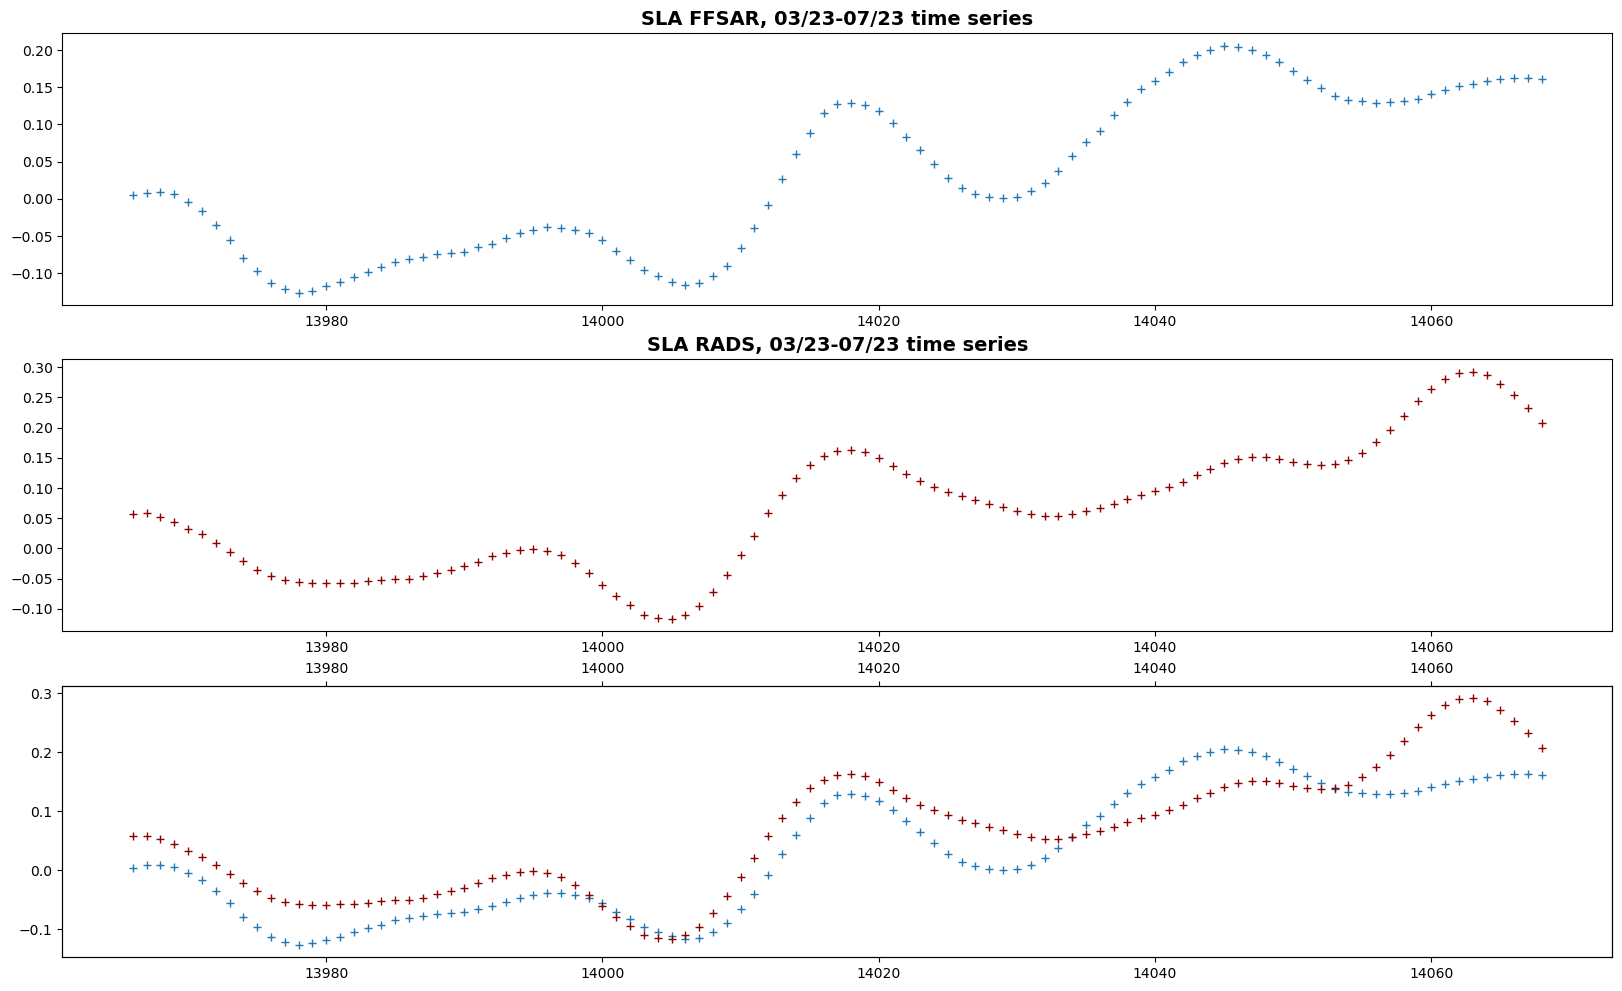

In [14]:
## TIME SERIES - for 1 point arbitrarily chosen on the first line for computation
## Note that this is only truly relevant for datasets with the same grid and the same choice of 'lines' for PSD computation

##Choose sources here
source1 = ffsarf1d
source2 = radsf1d


#####
# No changes to be made below this
#####
data1, yp1, xp1, t1 = source1['data'], source1['highpoint'] -15, source1['lines'][0], source1['time']
data2, yp2, xp2, t2 = source2['data'], source2['highpoint'] -15, source2['lines'][0], source2['time'] #21

def timese(data, xp, yp): 
    timese = []
    for i in range(len(data)) : 
        if (len(data[i].shape)) == 3 : 
            timese.append(data[i][0, yp, xp])
        else : 
            timese.append(data[i][yp, xp])
    return timese


fig, ax = plt.subplots(3, 1, figsize=(20, 12))
 
ts1 = timese(data1, xp1, yp1)

ax[0].plot(t1, ts1[:], '+')
ax[0].set_title(source1['label'] + ' time series', fontsize=14, fontweight='bold')

ts2 = timese(data2, xp2, yp2)

ax[1].plot(t2, ts2[:], '+', color='darkred')
ax[1].set_title(source2['label'] + ' time series', fontsize=14, fontweight='bold')

ax[2].plot(t1, ts1[:], '+')
ax2 = ax[2].twiny()
ax2.plot(t2, ts2, '+', color='darkred') #[2.5* t - np.mean(ts2) for t in 